In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import plotting as pl
from koala.voronization import generate_lattice
from koala.graph_color import color_lattice
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.lattice import Lattice
from scipy import linalg as la
from pfapack.pfaffian import pfaffian

from koala import example_graphs as eg
from dimer_models.koala_plantri import plantri_to_koala, plantri_generator, read_plantri
from dimer_models.lattice_generation import (
    bipartite_squarefull,
    reduce_bipartite,
)

from dimer_models.kasteleyn import kasteleyn_matrix, find_kasteleyn_number

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from copy import copy

In [26]:
ns = 300
lattice, og = bipartite_squarefull(ns, return_pre_expanded=True)
# lattice = gu.com_relaxation(lattice)

73 73


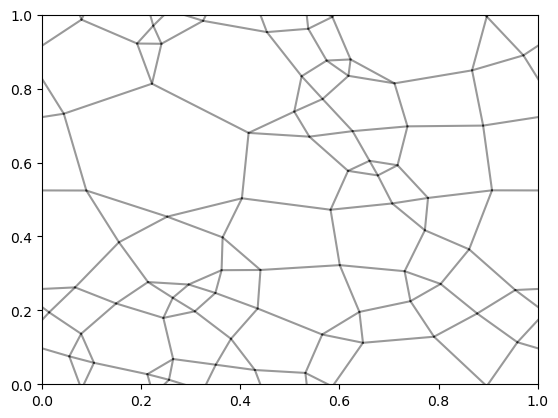

In [27]:
pl.plot_edges(og, alpha=0.4)
print(og.n_plaquettes, og.n_vertices)

In [28]:
find_kasteleyn_number(og)

ValueError: a system with periodic boundaries has an odd number to flip, this is a bug.

[0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0 1
 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0
 1 0 0 1 0 0 0 1 0 0 1 0 1 1 0 1 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0
 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


<Axes: >

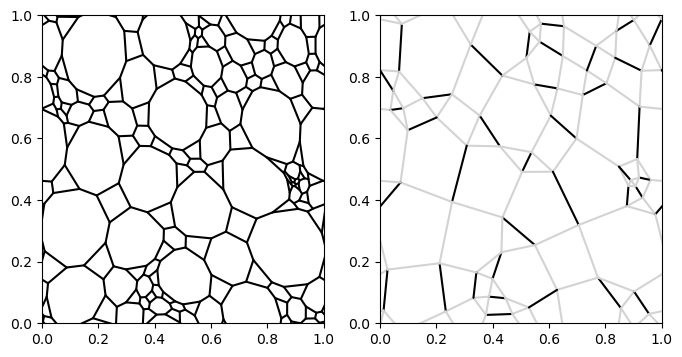

In [ ]:
dimer = gu.dimerise(og)
print(dimer)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
pl.plot_edges(lattice, ax=ax[0])
pl.plot_edges(og, ax=ax[1], labels=dimer, color_scheme=["lightgrey", "k"])

In [ ]:
# gu.remove_vertices()
from collections.abc import Iterable

<Axes: >

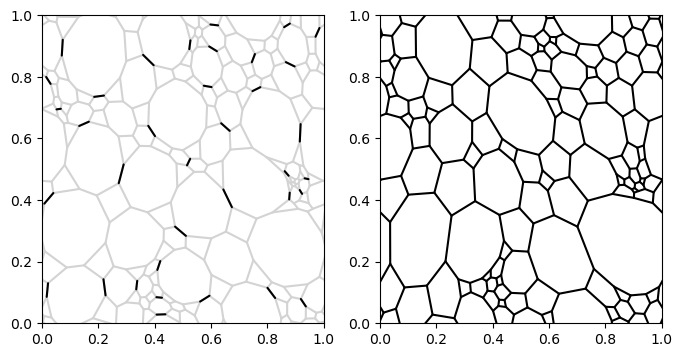

In [ ]:
from dimer_models.lattice_generation import expand_edges

edges_chosen = np.where(dimer)[0]

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
pl.plot_edges(lattice, ax=ax[0], color_scheme=["lightgrey"])
pl.plot_edges(lattice, ax=ax[0], color_scheme=["k"], subset=edges_chosen)
# pl.plot_edge_indices(lattice, ax=ax[0])

l2 = expand_edges(lattice, edges_chosen)

l2 = gu.com_relaxation(l2)
pl.plot_edges(l2, ax=ax[1])
# expand_edges(lattice, 2)

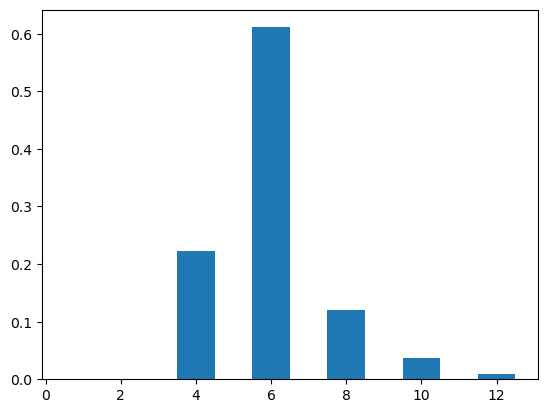

In [ ]:
n_sides = [p.n_sides for p in l2.plaquettes]

plt.hist(n_sides, bins=np.arange(1, max(n_sides) + 2) - 0.5, density=True)

plt.show()